# 02 - Ridge, Lasso and regularization diagnostics

This notebook uses Ridge and Lasso as **diagnostic tools** rather than as candidate winners.

The regularization chapter should answer:

1. **Ridge:** does coefficient shrinkage improve the linear model?
2. **Lasso:** can a sparser linear model preserve predictive performance?
3. **Generalization:** do train/CV gaps suggest overfitting, or is the linear model hitting a ceiling?
4. **Coefficients:** which transformed variables dominate the best linear, Ridge and Lasso models?
5. **Error structure:** does regularization change tail bias or prediction compression?

Methodological note:

- Numeric variables are standardized inside the sklearn pipeline.
- Categorical variables are one-hot encoded as 0/1 columns in this run.
- Coefficients are therefore coefficients of the transformed design, not causal effects.
- Bias-variance figures below use empirical proxies, not a formal decomposition, because the true conditional function is unknown.

## Output contract

This notebook writes final tables and figures to:

```text
reports/notebook_outputs/regularization_ridge_lasso_final/
```

Expected final tables:

```text
T1_model_regularization_summary.csv
T2_regularization_path_representative_points.csv
T3_selection_rules_best_vs_parsimonious.csv
T4_top_feature_families.csv
T5_p09_category_audit.csv
T6_distribution_error_summary.csv
T7_low_frequency_categories.csv
T8_top_feature_overlap.csv
```

Expected final figures:

```text
F1_ridge_shrinkage_cv_vs_l2_ratio.png
F2_lasso_sparsity_cv_vs_active_ratio.png
F3_regularization_decile_errors.png
F4_prediction_compression_dotplot.png
F5_p09_coefficients_by_category_share.png
F6_bias_variance_proxies_split_scale.png
```

## 00. Setup and backend ingestion

In [1]:
from pathlib import Path
import json
import yaml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Robust root resolution: works both from repo root and from notebooks/.
ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/home/matias/repos/income-modeling-eph"),
]

ROOT = next(
    (p for p in ROOT_CANDIDATES if (p / "reports" / "runs").exists()),
    Path("/home/matias/repos/income-modeling-eph"),
)

RUNS_DIR = ROOT / "reports" / "runs"
DATASET_PATH = ROOT / "data" / "processed" / "modeling_dataset.parquet"
OUTPUT_DIR = ROOT / "reports" / "notebook_outputs" / "regularization_ridge_lasso_final"
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)


def latest_run(pattern: str) -> Path:
    candidates = sorted(RUNS_DIR.glob(pattern), key=lambda p: p.name)
    if not candidates:
        raise FileNotFoundError(f"No runs found for pattern: {pattern}")
    return candidates[-1]


def read_csv_if_exists(path: Path) -> pd.DataFrame:
    if not path.exists():
        print(f"MISSING CSV: {path}")
        return pd.DataFrame()
    return pd.read_csv(path)


def read_parquet_if_exists(path: Path) -> pd.DataFrame:
    if not path.exists():
        print(f"MISSING PARQUET: {path}")
        return pd.DataFrame()
    return pd.read_parquet(path)


def read_json_if_exists(path: Path):
    if not path.exists():
        print(f"MISSING JSON: {path}")
        return None
    return json.loads(path.read_text())


def read_yaml_if_exists(path: Path):
    if not path.exists():
        print(f"MISSING YAML: {path}")
        return None
    return yaml.safe_load(path.read_text())


RUN_REG = latest_run("regularization_sweep_v1_*")
print("Regularization run:", RUN_REG)

try:
    RUN_HGB = latest_run("hgb_quick_benchmark_v1_*")
    print("HGB reference run:", RUN_HGB)
except FileNotFoundError:
    RUN_HGB = None
    print("HGB reference run not found; continuing without HGB.")

# Core regularization artifacts.
cv_linear = read_csv_if_exists(RUN_REG / "cv_results" / "LinearRegression.csv")
cv_ridge = read_csv_if_exists(RUN_REG / "cv_results" / "Ridge.csv")
cv_lasso = read_csv_if_exists(RUN_REG / "cv_results" / "Lasso.csv")

model_comparison = read_csv_if_exists(RUN_REG / "metrics" / "model_comparison.csv")
metrics_long = read_csv_if_exists(RUN_REG / "metrics" / "metrics_long.csv")

ridge_path_summary = read_csv_if_exists(RUN_REG / "diagnostics" / "Ridge_regularization_path_summary.csv")
lasso_path_summary = read_csv_if_exists(RUN_REG / "diagnostics" / "Lasso_regularization_path_summary.csv")

coef_ols = read_csv_if_exists(RUN_REG / "diagnostics" / "LinearRegression_best_coefficients.csv")
coef_ridge = read_csv_if_exists(RUN_REG / "diagnostics" / "Ridge_best_coefficients.csv")
coef_lasso = read_csv_if_exists(RUN_REG / "diagnostics" / "Lasso_best_coefficients.csv")

residual_summary = read_csv_if_exists(RUN_REG / "diagnostics" / "residual_summary.csv")
prediction_distribution_summary = read_csv_if_exists(RUN_REG / "diagnostics" / "prediction_distribution_summary.csv")
error_by_decile = read_csv_if_exists(RUN_REG / "diagnostics" / "error_by_income_decile.csv")
compression_summary = read_csv_if_exists(RUN_REG / "diagnostics" / "distribution_compression_summary.csv")

pred_test = read_parquet_if_exists(RUN_REG / "predictions" / "test_predictions.parquet")
pred_validation = read_parquet_if_exists(RUN_REG / "predictions" / "validation_predictions.parquet")

if not pred_test.empty:
    pred_test["split"] = "test"
if not pred_validation.empty:
    pred_validation["split"] = "validation"
predictions = pd.concat([pred_test, pred_validation], ignore_index=True)

feature_columns = read_json_if_exists(RUN_REG / "feature_columns.json")
dataset_card = read_json_if_exists(RUN_REG / "dataset_card.json")
experiment_card = read_json_if_exists(RUN_REG / "experiment_card.json")
run_manifest = read_json_if_exists(RUN_REG / "run_manifest.json")
config_used = read_yaml_if_exists(RUN_REG / "config_used.yaml")

# Optional HGB reference artifacts.
if RUN_HGB is not None:
    hgb_model_comparison = read_csv_if_exists(RUN_HGB / "metrics" / "model_comparison.csv")
    hgb_error_by_decile = read_csv_if_exists(RUN_HGB / "diagnostics" / "error_by_income_decile.csv")
    hgb_compression_summary = read_csv_if_exists(RUN_HGB / "diagnostics" / "distribution_compression_summary.csv")
    hgb_prediction_distribution = read_csv_if_exists(RUN_HGB / "diagnostics" / "prediction_distribution_summary.csv")
else:
    hgb_model_comparison = pd.DataFrame()
    hgb_error_by_decile = pd.DataFrame()
    hgb_compression_summary = pd.DataFrame()
    hgb_prediction_distribution = pd.DataFrame()

for name, df in {
    "cv_linear": cv_linear,
    "cv_ridge": cv_ridge,
    "cv_lasso": cv_lasso,
    "model_comparison": model_comparison,
    "ridge_path_summary": ridge_path_summary,
    "lasso_path_summary": lasso_path_summary,
    "coef_ols": coef_ols,
    "coef_ridge": coef_ridge,
    "coef_lasso": coef_lasso,
    "residual_summary": residual_summary,
    "prediction_distribution_summary": prediction_distribution_summary,
    "error_by_decile": error_by_decile,
    "compression_summary": compression_summary,
    "predictions": predictions,
    "hgb_model_comparison": hgb_model_comparison,
}.items():
    print(f"{name:40s} {df.shape}")

ROOT: /home/matias/repos/income-modeling-eph
OUTPUT_DIR: /home/matias/repos/income-modeling-eph/reports/notebook_outputs/regularization_ridge_lasso_final
Regularization run: /home/matias/repos/income-modeling-eph/reports/runs/regularization_sweep_v1_20260609T062726Z
HGB reference run: /home/matias/repos/income-modeling-eph/reports/runs/hgb_quick_benchmark_v1_20260609T061007Z
MISSING CSV: /home/matias/repos/income-modeling-eph/reports/runs/regularization_sweep_v1_20260609T062726Z/diagnostics/distribution_compression_summary.csv
cv_linear                                (1, 19)
cv_ridge                                 (17, 20)
cv_lasso                                 (13, 21)
model_comparison                         (3, 12)
ridge_path_summary                       (17, 10)
lasso_path_summary                       (13, 10)
coef_ols                                 (51, 6)
coef_ridge                               (51, 6)
coef_lasso                               (51, 6)
residual_summary      

## 01. Analysis helpers and dataframes

In [2]:
def first_existing(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None


def prepare_cv_path(df: pd.DataFrame, model_name: str) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()

    out = df.copy()
    out["model"] = model_name
    out["cv_r2"] = pd.to_numeric(out["mean_test_score"], errors="coerce")
    out["train_r2"] = pd.to_numeric(out.get("mean_train_score", np.nan), errors="coerce")
    out["train_cv_gap"] = out["train_r2"] - out["cv_r2"]
    out["cv_r2_std"] = pd.to_numeric(out.get("std_test_score", np.nan), errors="coerce")

    # Current run uses 3-fold CV. Make this dynamic if CV folds change later.
    out["cv_r2_se"] = out["cv_r2_std"] / np.sqrt(3)

    if "param_reg__alpha" in out.columns:
        out["alpha"] = pd.to_numeric(out["param_reg__alpha"], errors="coerce")
    else:
        out["alpha"] = np.nan

    out["cv_r2_loss_from_best"] = out["cv_r2"].max() - out["cv_r2"]
    return out


def normalize_path_summary(df: pd.DataFrame, model_name: str) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()

    out = df.copy()
    out["model"] = model_name

    rename_map = {}
    for c in out.columns:
        lc = c.lower()
        if lc in {"coefficient_l1_norm", "coef_l1_norm", "l1_norm"}:
            rename_map[c] = "coef_l1_norm"
        if lc in {"coefficient_l2_norm", "coef_l2_norm", "l2_norm"}:
            rename_map[c] = "coef_l2_norm"
        if lc in {"nonzero_coefficients", "n_nonzero", "nonzero"}:
            rename_map[c] = "nonzero_coefficients"
        if lc == "mean_cv_score":
            rename_map[c] = "cv_r2_path"
        if lc == "mean_train_score":
            rename_map[c] = "train_r2_path"

    out = out.rename(columns=rename_map)

    if "alpha" not in out.columns and "param_reg__alpha" in out.columns:
        out["alpha"] = pd.to_numeric(out["param_reg__alpha"], errors="coerce")
    elif "alpha" in out.columns:
        out["alpha"] = pd.to_numeric(out["alpha"], errors="coerce")

    return out


def parse_raw_feature(feature: str, feature_columns: list[str] | None) -> str:
    name = str(feature)

    if name.startswith("num__"):
        return name.replace("num__", "", 1)

    if name.startswith("cat__"):
        tail = name.replace("cat__", "", 1)
        if feature_columns:
            candidates = sorted(
                [c for c in feature_columns if tail == c or tail.startswith(f"{c}_")],
                key=len,
                reverse=True,
            )
            if candidates:
                return candidates[0]
        return tail.rsplit("_", 1)[0]

    return name


def normalize_coef_table(df: pd.DataFrame, model_name: str) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()

    out = df.copy()
    out["model"] = model_name

    feature_col = next((c for c in ["feature", "feature_name", "term", "variable"] if c in out.columns), None)
    coef_col = next((c for c in ["coefficient", "coef", "value"] if c in out.columns), None)

    if feature_col is None or coef_col is None:
        raise ValueError(f"Could not infer coefficient columns for {model_name}: {out.columns.tolist()}")

    if feature_col != "feature":
        out = out.rename(columns={feature_col: "feature"})
    if coef_col != "coefficient":
        out = out.rename(columns={coef_col: "coefficient"})

    out["coefficient"] = pd.to_numeric(out["coefficient"], errors="coerce")
    out["abs_coefficient"] = out["coefficient"].abs()
    out["sign"] = np.where(out["coefficient"] > 0, "positive", np.where(out["coefficient"] < 0, "negative", "zero"))
    out["is_nonzero"] = out["abs_coefficient"] > 1e-12
    out["feature_block"] = np.where(
        out["feature"].str.startswith("num__"),
        "numeric",
        np.where(out["feature"].str.startswith("cat__"), "categorical", "other"),
    )
    out["raw_feature"] = out["feature"].apply(lambda x: parse_raw_feature(x, feature_columns))

    return out


cv_paths = pd.concat(
    [
        prepare_cv_path(cv_linear, "LinearRegression"),
        prepare_cv_path(cv_ridge, "Ridge"),
        prepare_cv_path(cv_lasso, "Lasso"),
    ],
    ignore_index=True,
)

ridge_path = normalize_path_summary(ridge_path_summary, "Ridge")
lasso_path = normalize_path_summary(lasso_path_summary, "Lasso")
path_summary = pd.concat([ridge_path, lasso_path], ignore_index=True)

if not path_summary.empty:
    path_merge_cols = [c for c in path_summary.columns if c not in {"run_id"}]
    regularization_path = cv_paths.merge(
        path_summary[path_merge_cols],
        on=["model", "alpha"],
        how="left",
        suffixes=("", "_path"),
    )
else:
    regularization_path = cv_paths.copy()

if "coef_l2_norm" in regularization_path.columns:
    regularization_path["l2_ratio"] = regularization_path["coef_l2_norm"] / regularization_path.groupby("model")["coef_l2_norm"].transform("max")
    regularization_path["relative_l2_norm"] = regularization_path["l2_ratio"]
if "coef_l1_norm" in regularization_path.columns:
    regularization_path["l1_ratio"] = regularization_path["coef_l1_norm"] / regularization_path.groupby("model")["coef_l1_norm"].transform("max")
    regularization_path["relative_l1_norm"] = regularization_path["l1_ratio"]
if "nonzero_coefficients" in regularization_path.columns:
    regularization_path["active_ratio"] = regularization_path["nonzero_coefficients"] / regularization_path.groupby("model")["nonzero_coefficients"].transform("max")

regularization_path["cv_error_proxy"] = 1 - regularization_path["cv_r2"]
regularization_path["train_error_proxy"] = 1 - regularization_path["train_r2"]

best_by_model = (
    regularization_path
    .sort_values("cv_r2", ascending=False)
    .groupby("model")
    .head(1)
    .reset_index(drop=True)
)

one_se_rows = []
for model_name, g in regularization_path.dropna(subset=["alpha"]).groupby("model"):
    g = g.copy()
    best = g.sort_values("cv_r2", ascending=False).iloc[0]
    threshold = best["cv_r2"] - best["cv_r2_se"]
    candidates = g[g["cv_r2"] >= threshold].copy()
    if candidates.empty:
        continue
    chosen = candidates.sort_values("alpha", ascending=False).iloc[0]
    row = chosen.to_dict()
    row["selection_rule"] = "one_se_strongest_regularization"
    row["best_cv_r2"] = best["cv_r2"]
    row["one_se_threshold"] = threshold
    one_se_rows.append(row)
one_se_selection = pd.DataFrame(one_se_rows)

within_005_rows = []
for model_name, g in regularization_path.dropna(subset=["alpha"]).groupby("model"):
    g = g.copy()
    candidates = g[g["cv_r2_loss_from_best"] <= 0.005].copy()
    if candidates.empty:
        continue
    chosen = candidates.sort_values("alpha", ascending=False).iloc[0]
    row = chosen.to_dict()
    row["selection_rule"] = "within_0p005_r2_of_best"
    within_005_rows.append(row)
within_005_selection = pd.DataFrame(within_005_rows)

coef_table = pd.concat(
    [
        normalize_coef_table(coef_ols, "LinearRegression"),
        normalize_coef_table(coef_ridge, "Ridge"),
        normalize_coef_table(coef_lasso, "Lasso"),
    ],
    ignore_index=True,
)

top_coefficients = (
    coef_table
    .sort_values("abs_coefficient", ascending=False)
    .groupby("model")
    .head(25)
    .reset_index(drop=True)
)

if not predictions.empty:
    if "residual" not in predictions.columns:
        predictions["residual"] = predictions["y_true"] - predictions["y_pred"]
    if "abs_error" not in predictions.columns:
        predictions["abs_error"] = predictions["residual"].abs()
    if "squared_error" not in predictions.columns:
        predictions["squared_error"] = predictions["residual"] ** 2

bias_variance_proxy = regularization_path.copy()
bias_variance_proxy["underfit_proxy"] = 1 - bias_variance_proxy["train_r2"]
bias_variance_proxy["generalization_gap"] = bias_variance_proxy["train_r2"] - bias_variance_proxy["cv_r2"]
bias_variance_proxy["cv_instability"] = bias_variance_proxy["cv_r2_std"]

for name, df in {
    "cv_paths": cv_paths,
    "regularization_path": regularization_path,
    "best_by_model": best_by_model,
    "one_se_selection": one_se_selection,
    "within_005_selection": within_005_selection,
    "coef_table": coef_table,
    "top_coefficients": top_coefficients,
    "bias_variance_proxy": bias_variance_proxy,
    "predictions": predictions,
}.items():
    print(f"{name:36s} {df.shape}")

cv_paths                             (31, 28)
regularization_path                  (31, 42)
best_by_model                        (3, 42)
one_se_selection                     (2, 45)
within_005_selection                 (2, 43)
coef_table                           (153, 10)
top_coefficients                     (75, 10)
bias_variance_proxy                  (31, 45)
predictions                          (45000, 10)


## 02. Final result tables

In [3]:
# T1 - compact best-model regularization summary
T1_cols = [
    "model",
    "alpha",
    "cv_r2",
    "cv_r2_std",
    "cv_r2_se",
    "train_r2",
    "train_cv_gap",
    "coef_l1_norm",
    "coef_l2_norm",
    "nonzero_coefficients",
    "l1_ratio",
    "l2_ratio",
    "active_ratio",
]
T1_cols = [c for c in T1_cols if c in best_by_model.columns]

T1_model_regularization_summary = (
    best_by_model[T1_cols]
    .sort_values("cv_r2", ascending=False)
    .reset_index(drop=True)
)

T1_model_regularization_summary.to_csv(TABLE_DIR / "T1_model_regularization_summary.csv", index=False)
T1_model_regularization_summary.round(6)

,model,alpha,cv_r2,cv_r2_std,cv_r2_se,train_r2,train_cv_gap,coef_l1_norm,coef_l2_norm,nonzero_coefficients,l1_ratio,l2_ratio,active_ratio
0,Lasso,0.000022,0.408581,0.012973,0.007490,0.416480,0.007898,3.403567,1.132167,50.0,0.985864,0.980216,1.0
1,LinearRegression,NaN,0.408554,0.012890,0.007442,0.416494,0.007940,NaN,NaN,NaN,NaN,NaN,NaN
2,Ridge,0.000100,0.408550,0.012888,0.007441,0.416494,0.007943,3.794342,1.036124,51.0,1.000000,1.000000,1.0


In [4]:
# T2 - representative points along the regularization path
representative_rows = []

representative_alphas = {
    "Ridge": [0.0001, 10.0, 31.6228, 100.0, 1000.0, 10000.0],
    "Lasso": [0.00001, 0.000464159, 0.001, 0.01, 0.0464159, 0.1],
}

for model_name, alphas in representative_alphas.items():
    g = regularization_path.query("model == @model_name").copy()
    if g.empty:
        continue
    for alpha in alphas:
        idx = (g["alpha"] - alpha).abs().idxmin()
        representative_rows.append(g.loc[idx])

T2_regularization_path_representative_points = pd.DataFrame(representative_rows).drop_duplicates(
    subset=["model", "alpha"]
)

T2_cols = [
    "model",
    "alpha",
    "cv_r2",
    "cv_r2_loss_from_best",
    "train_r2",
    "train_cv_gap",
    "coef_l1_norm",
    "coef_l2_norm",
    "l1_ratio",
    "l2_ratio",
    "nonzero_coefficients",
    "active_ratio",
]
T2_cols = [c for c in T2_cols if c in T2_regularization_path_representative_points.columns]

T2_regularization_path_representative_points = (
    T2_regularization_path_representative_points[T2_cols]
    .sort_values(["model", "alpha"])
    .reset_index(drop=True)
)

T2_regularization_path_representative_points.to_csv(
    TABLE_DIR / "T2_regularization_path_representative_points.csv",
    index=False,
)

T2_regularization_path_representative_points.round(6)

,model,alpha,cv_r2,cv_r2_loss_from_best,train_r2,train_cv_gap,coef_l1_norm,coef_l2_norm,l1_ratio,l2_ratio,nonzero_coefficients,active_ratio
0,Lasso,0.000010,0.408569,0.000013,0.416491,0.007922,3.452369,1.155017,1.000000,1.000000,50.0,1.00
1,Lasso,0.000464,0.404046,0.004535,0.411429,0.007383,1.765531,0.465227,0.511397,0.402787,43.0,0.86
2,Lasso,0.001000,0.398960,0.009621,0.406038,0.007078,1.186384,0.310991,0.343643,0.269252,38.0,0.76
3,Lasso,0.010000,0.365993,0.042589,0.370478,0.004486,0.574377,0.196580,0.166372,0.170196,22.0,0.44
4,Lasso,0.046416,0.239103,0.169478,0.242348,0.003245,0.234626,0.106372,0.067961,0.092095,8.0,0.16
5,Lasso,0.100000,0.062108,0.346473,0.064863,0.002755,0.037791,0.037791,0.010946,0.032719,1.0,0.02
6,Ridge,0.000100,0.408550,0.000000,0.416494,0.007943,3.794342,1.036124,1.000000,1.000000,51.0,1.00
7,Ridge,10.000000,0.408009,0.000542,0.415966,0.007957,3.325439,0.868893,0.876420,0.838599,51.0,1.00
8,Ridge,31.622800,0.406348,0.002202,0.414315,0.007967,2.751793,0.678006,0.725236,0.654368,51.0,1.00
9,Ridge,100.000000,0.403181,0.005369,0.411144,0.007963,2.043824,0.470136,0.538650,0.453745,51.0,1.00


In [5]:
# T3 - selection rules: best vs parsimonious regularization
best_selection = best_by_model.copy()
best_selection["selection_rule"] = "best_cv_r2"
best_selection["best_cv_r2"] = best_selection["cv_r2"]

selection_frames = [best_selection]

if not within_005_selection.empty:
    selection_frames.append(within_005_selection)
if not one_se_selection.empty:
    selection_frames.append(one_se_selection)

T3_selection_rules_best_vs_parsimonious = pd.concat(selection_frames, ignore_index=True)

T3_cols = [
    "model",
    "selection_rule",
    "alpha",
    "cv_r2",
    "best_cv_r2",
    "one_se_threshold",
    "cv_r2_loss_from_best",
    "train_r2",
    "train_cv_gap",
    "coef_l1_norm",
    "coef_l2_norm",
    "l1_ratio",
    "l2_ratio",
    "nonzero_coefficients",
    "active_ratio",
]
T3_cols = [c for c in T3_cols if c in T3_selection_rules_best_vs_parsimonious.columns]

T3_selection_rules_best_vs_parsimonious = (
    T3_selection_rules_best_vs_parsimonious[T3_cols]
    .sort_values(["model", "selection_rule"])
    .reset_index(drop=True)
)

T3_selection_rules_best_vs_parsimonious.to_csv(
    TABLE_DIR / "T3_selection_rules_best_vs_parsimonious.csv",
    index=False,
)

T3_selection_rules_best_vs_parsimonious.round(6)

,model,selection_rule,alpha,cv_r2,best_cv_r2,one_se_threshold,cv_r2_loss_from_best,train_r2,train_cv_gap,coef_l1_norm,coef_l2_norm,l1_ratio,l2_ratio,nonzero_coefficients,active_ratio
0,Lasso,best_cv_r2,0.000022,0.408581,0.408581,NaN,0.000000,0.416480,0.007898,3.403567,1.132167,0.985864,0.980216,50.0,1.00
1,Lasso,one_se_strongest_regularization,0.000464,0.404046,0.408581,0.401091,0.004535,0.411429,0.007383,1.765531,0.465227,0.511397,0.402787,43.0,0.86
2,Lasso,within_0p005_r2_of_best,0.000464,0.404046,NaN,NaN,0.004535,0.411429,0.007383,1.765531,0.465227,0.511397,0.402787,43.0,0.86
3,LinearRegression,best_cv_r2,NaN,0.408554,0.408554,NaN,0.000000,0.416494,0.007940,NaN,NaN,NaN,NaN,NaN,NaN
4,Ridge,best_cv_r2,0.000100,0.408550,0.408550,NaN,0.000000,0.416494,0.007943,3.794342,1.036124,1.000000,1.000000,51.0,1.00
5,Ridge,one_se_strongest_regularization,100.000000,0.403181,0.408550,0.401109,0.005369,0.411144,0.007963,2.043824,0.470136,0.538650,0.453745,51.0,1.00
6,Ridge,within_0p005_r2_of_best,31.622800,0.406348,NaN,NaN,0.002202,0.414315,0.007967,2.751793,0.678006,0.725236,0.654368,51.0,1.00


In [6]:
# T4 - top feature families
top_n = 20
top_features = (
    coef_table
    .sort_values("abs_coefficient", ascending=False)
    .groupby("model")
    .head(top_n)
)

T4_top_feature_families = (
    top_features
    .groupby(["model", "raw_feature", "feature_block"])
    .agg(
        n_top20=("feature", "size"),
        max_abs_coefficient=("abs_coefficient", "max"),
        mean_abs_coefficient=("abs_coefficient", "mean"),
        max_positive_coefficient=("coefficient", "max"),
        min_negative_coefficient=("coefficient", "min"),
    )
    .reset_index()
    .sort_values(["model", "n_top20", "max_abs_coefficient"], ascending=[True, False, False])
)

T4_top_feature_families.to_csv(TABLE_DIR / "T4_top_feature_families.csv", index=False)
T4_top_feature_families.round(6)

,model,raw_feature,feature_block,n_top20,max_abs_coefficient,mean_abs_coefficient,max_positive_coefficient,min_negative_coefficient
6,Lasso,P09,categorical,10,0.660833,0.246698,0.660833,-0.167309
2,Lasso,CAT_OCUP,numeric,1,0.140616,0.140616,0.140616,0.140616
5,Lasso,P03,numeric,1,0.137243,0.137243,0.137243,0.137243
7,Lasso,P10,numeric,1,0.097757,0.097757,-0.097757,-0.097757
8,Lasso,PP07G_59,numeric,1,0.072153,0.072153,-0.072153,-0.072153
10,Lasso,Region,categorical,1,0.059208,0.059208,0.059208,0.059208
4,Lasso,P02,numeric,1,0.045762,0.045762,-0.045762,-0.045762
1,Lasso,CAT_INAC,numeric,1,0.041016,0.041016,-0.041016,-0.041016
0,Lasso,AGLO_rk,numeric,1,0.031864,0.031864,0.031864,0.031864
9,Lasso,Personas_25-64,numeric,1,0.028683,0.028683,-0.028683,-0.028683


In [7]:
# T8 - top feature overlap
top_feature_sets = {
    model_name: set(
        coef_table
        .query("model == @model_name")
        .sort_values("abs_coefficient", ascending=False)
        .head(top_n)["feature"]
    )
    for model_name in sorted(coef_table["model"].unique())
}

overlap_rows = []
models = list(top_feature_sets)

for i, m1 in enumerate(models):
    for m2 in models[i + 1:]:
        overlap_rows.append({
            "model_a": m1,
            "model_b": m2,
            "top_n": top_n,
            "overlap": len(top_feature_sets[m1] & top_feature_sets[m2]),
            "jaccard": len(top_feature_sets[m1] & top_feature_sets[m2]) / len(top_feature_sets[m1] | top_feature_sets[m2]),
        })

T8_top_feature_overlap = pd.DataFrame(overlap_rows)
T8_top_feature_overlap.to_csv(TABLE_DIR / "T8_top_feature_overlap.csv", index=False)
T8_top_feature_overlap.round(4)

,model_a,model_b,top_n,overlap,jaccard
0,Lasso,LinearRegression,20,19,0.9048
1,Lasso,Ridge,20,19,0.9048
2,LinearRegression,Ridge,20,20,1.0000


## 03. Ridge final figures

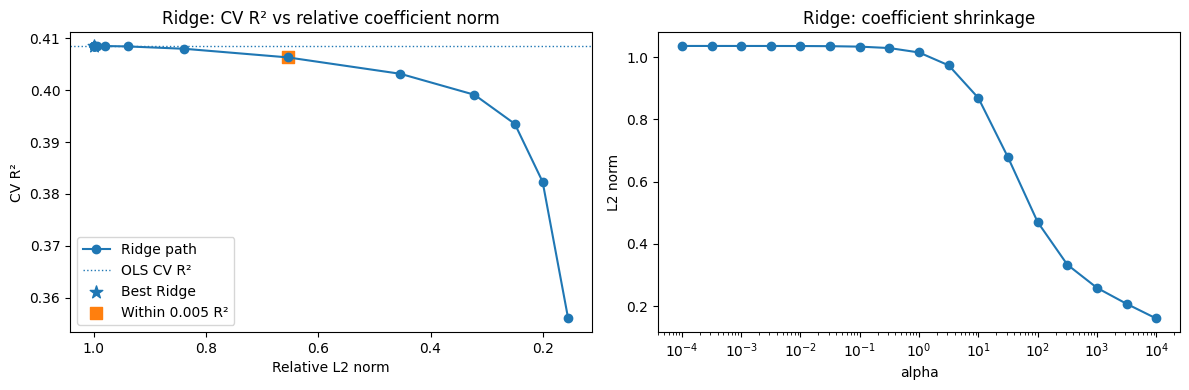

In [8]:
ridge = regularization_path.query("model == 'Ridge'").sort_values("alpha").copy()
ols_cv_r2 = cv_paths.query("model == 'LinearRegression'")["cv_r2"].iloc[0]

ridge_best = ridge.sort_values("cv_r2", ascending=False).iloc[0]
ridge_within = within_005_selection.query("model == 'Ridge'")
ridge_within = ridge_within.iloc[0] if not ridge_within.empty else None

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel A: CV R2 vs relative L2 norm
axes[0].plot(ridge["l2_ratio"], ridge["cv_r2"], marker="o", label="Ridge path")
axes[0].axhline(ols_cv_r2, linewidth=1, linestyle=":", label="OLS CV R²")
axes[0].scatter([ridge_best["l2_ratio"]], [ridge_best["cv_r2"]], s=90, marker="*", label="Best Ridge")

if ridge_within is not None:
    axes[0].scatter([ridge_within["l2_ratio"]], [ridge_within["cv_r2"]], s=70, marker="s", label="Within 0.005 R²")

axes[0].invert_xaxis()
axes[0].set_xlabel("Relative L2 norm")
axes[0].set_ylabel("CV R²")
axes[0].set_title("Ridge: CV R² vs relative coefficient norm")
axes[0].legend()

# Panel B: coefficient norm vs alpha
axes[1].plot(ridge["alpha"], ridge["coef_l2_norm"], marker="o")
axes[1].set_xscale("log")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("L2 norm")
axes[1].set_title("Ridge: coefficient shrinkage")

plt.tight_layout()
plt.savefig(FIG_DIR / "F1_ridge_shrinkage_cv_vs_l2_ratio.png", dpi=180, bbox_inches="tight")
plt.show()

## 04. Lasso final figures

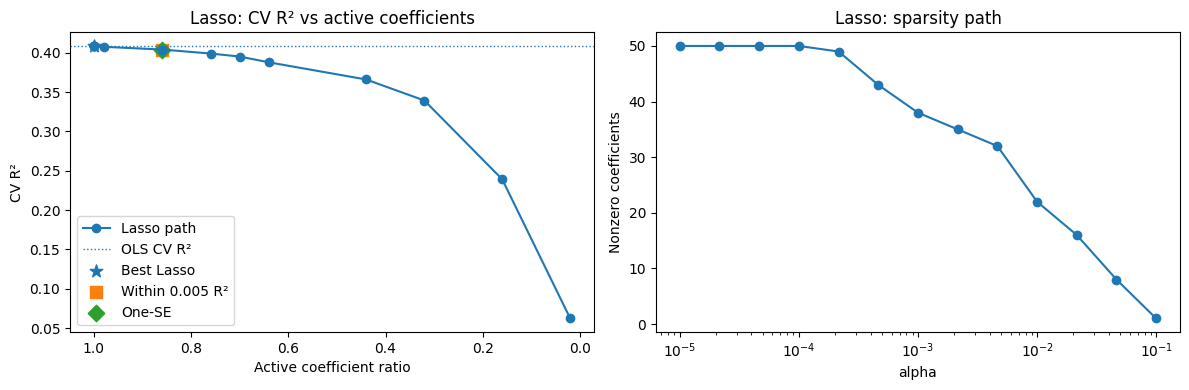

In [9]:
lasso = regularization_path.query("model == 'Lasso'").sort_values("alpha").copy()

lasso_best = lasso.sort_values("cv_r2", ascending=False).iloc[0]
lasso_within = within_005_selection.query("model == 'Lasso'")
lasso_within = lasso_within.iloc[0] if not lasso_within.empty else None
lasso_one_se = one_se_selection.query("model == 'Lasso'")
lasso_one_se = lasso_one_se.iloc[0] if not lasso_one_se.empty else None

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel A: CV R2 vs active ratio
axes[0].plot(lasso["active_ratio"], lasso["cv_r2"], marker="o", label="Lasso path")
axes[0].axhline(ols_cv_r2, linewidth=1, linestyle=":", label="OLS CV R²")
axes[0].scatter([lasso_best["active_ratio"]], [lasso_best["cv_r2"]], s=90, marker="*", label="Best Lasso")

if lasso_within is not None:
    axes[0].scatter([lasso_within["active_ratio"]], [lasso_within["cv_r2"]], s=70, marker="s", label="Within 0.005 R²")

if lasso_one_se is not None:
    axes[0].scatter([lasso_one_se["active_ratio"]], [lasso_one_se["cv_r2"]], s=70, marker="D", label="One-SE")

axes[0].invert_xaxis()
axes[0].set_xlabel("Active coefficient ratio")
axes[0].set_ylabel("CV R²")
axes[0].set_title("Lasso: CV R² vs active coefficients")
axes[0].legend()

# Panel B: nonzero coefficients vs alpha
axes[1].plot(lasso["alpha"], lasso["nonzero_coefficients"], marker="o")
axes[1].set_xscale("log")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("Nonzero coefficients")
axes[1].set_title("Lasso: sparsity path")

plt.tight_layout()
plt.savefig(FIG_DIR / "F2_lasso_sparsity_cv_vs_active_ratio.png", dpi=180, bbox_inches="tight")
plt.show()

## 05. Decile error structure

decile_col: income_decile
mae_col: abs_error_mean
resid_col: residual_mean


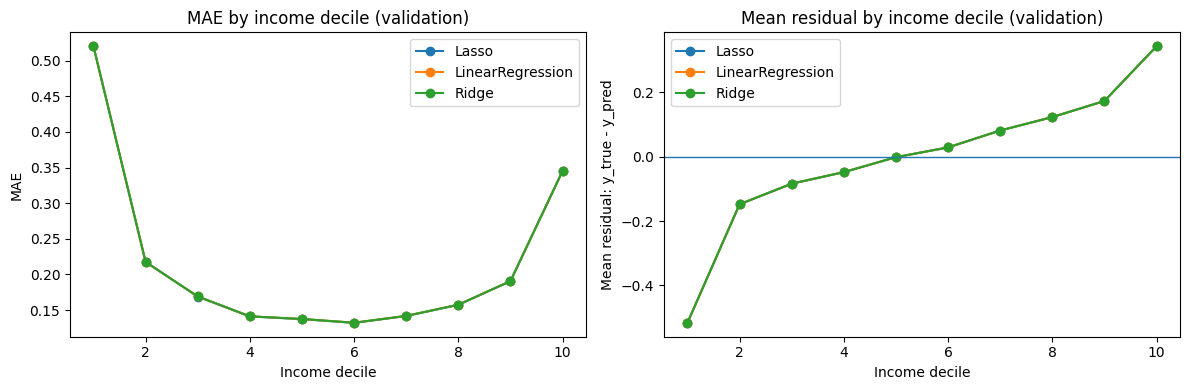

In [10]:
decile_col = first_existing(error_by_decile.columns, ["income_decile", "decile", "y_true_decile"])
mae_col = first_existing(error_by_decile.columns, ["mae", "abs_error_mean", "mean_abs_error", "mae_mean"])
resid_col = first_existing(error_by_decile.columns, ["residual_mean", "mean_residual", "residual"])

print("decile_col:", decile_col)
print("mae_col:", mae_col)
print("resid_col:", resid_col)

split_name = "validation"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for model_name, g in error_by_decile.query("split == @split_name").groupby("model"):
    g = g.sort_values(decile_col)

    if mae_col is not None:
        axes[0].plot(g[decile_col], g[mae_col], marker="o", label=model_name)

    if resid_col is not None:
        axes[1].plot(g[decile_col], g[resid_col], marker="o", label=model_name)

axes[0].set_xlabel("Income decile")
axes[0].set_ylabel("MAE")
axes[0].set_title(f"MAE by income decile ({split_name})")

axes[1].axhline(0, linewidth=1)
axes[1].set_xlabel("Income decile")
axes[1].set_ylabel("Mean residual: y_true - y_pred")
axes[1].set_title(f"Mean residual by income decile ({split_name})")

axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "F3_regularization_decile_errors.png", dpi=180, bbox_inches="tight")
plt.show()

## 06. Prediction compression dot plot

,source,model,split,row_count,y_true_std,y_pred_std,std_ratio,y_true_min,y_pred_min,y_true_max,y_pred_max,range_ratio
0,regularization,Lasso,test,10000,0.377628,0.243165,0.643928,2.012837,2.794835,5.048077,4.443255,0.543094
1,regularization,Lasso,validation,5000,0.385642,0.242617,0.629125,2.004321,2.764735,5.196905,4.579414,0.568405
2,regularization,LinearRegression,test,10000,0.377628,0.243476,0.644752,2.012837,2.793909,5.048077,4.444945,0.543956
3,regularization,LinearRegression,validation,5000,0.385642,0.242939,0.629960,2.004321,2.768867,5.196905,4.581818,0.567863
4,regularization,Ridge,test,10000,0.377628,0.243476,0.644752,2.012837,2.793909,5.048077,4.444945,0.543956
5,regularization,Ridge,validation,5000,0.385642,0.242939,0.629960,2.004321,2.768866,5.196905,4.581818,0.567863
6,hgb_reference,HistGradientBoostingRegressor,test,20000,0.378994,0.281434,0.742581,2.008600,2.396715,5.808967,4.490077,0.550832
7,hgb_reference,HistGradientBoostingRegressor,validation,10000,0.378539,0.278076,0.734605,2.004321,2.409276,5.225079,4.460709,0.636941


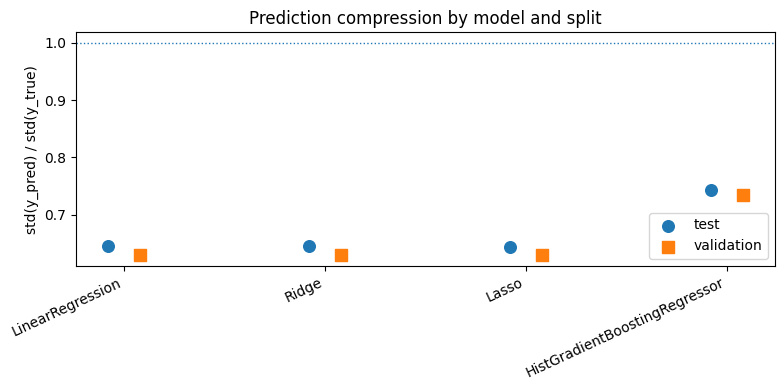

In [11]:
# Build compression table from prediction_distribution_summary if full compression summary is missing.
dist = prediction_distribution_summary.copy()

if not dist.empty:
    dist["std_ratio"] = dist["y_pred_std"] / dist["y_true_std"]
    dist["range_ratio"] = (
        (dist["y_pred_max"] - dist["y_pred_min"])
        / (dist["y_true_max"] - dist["y_true_min"])
    )
    dist["source"] = "regularization"
else:
    dist = pd.DataFrame()

hgb_dist = hgb_prediction_distribution.copy()
if not hgb_dist.empty:
    hgb_dist["std_ratio"] = hgb_dist["y_pred_std"] / hgb_dist["y_true_std"]
    hgb_dist["range_ratio"] = (
        (hgb_dist["y_pred_max"] - hgb_dist["y_pred_min"])
        / (hgb_dist["y_true_max"] - hgb_dist["y_true_min"])
    )
    hgb_dist["source"] = "hgb_reference"

dist_all = pd.concat([dist, hgb_dist], ignore_index=True)

# Keep relevant columns for thesis table.
T6_cols = [
    "source",
    "model",
    "split",
    "row_count",
    "y_true_std",
    "y_pred_std",
    "std_ratio",
    "y_true_min",
    "y_pred_min",
    "y_true_max",
    "y_pred_max",
    "range_ratio",
]
T6_cols = [c for c in T6_cols if c in dist_all.columns]

T6_distribution_error_summary = dist_all[T6_cols].copy()
T6_distribution_error_summary.to_csv(TABLE_DIR / "T6_distribution_error_summary.csv", index=False)

display(T6_distribution_error_summary.round(6))

# Dot plot.
plot_df = T6_distribution_error_summary.query("split in ['test', 'validation']").copy()
if not plot_df.empty:
    # Sort models with linear first, HGB last if present.
    preferred_order = ["LinearRegression", "Ridge", "Lasso", "HistGradientBoostingRegressor"]
    model_order = [m for m in preferred_order if m in plot_df["model"].unique()]
    model_order += [m for m in plot_df["model"].unique() if m not in model_order]

    x_positions = {m: i for i, m in enumerate(model_order)}
    split_offsets = {"test": -0.08, "validation": 0.08}
    split_markers = {"test": "o", "validation": "s"}

    fig, ax = plt.subplots(figsize=(8, 4))

    for split, g in plot_df.groupby("split"):
        xs = [x_positions[m] + split_offsets.get(split, 0) for m in g["model"]]
        ax.scatter(xs, g["std_ratio"], marker=split_markers.get(split, "o"), s=70, label=split)

    ax.axhline(1, linewidth=1, linestyle=":")
    ax.set_xticks(range(len(model_order)))
    ax.set_xticklabels(model_order, rotation=25, ha="right")
    ax.set_ylabel("std(y_pred) / std(y_true)")
    ax.set_title("Prediction compression by model and split")
    ax.legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR / "F4_prediction_compression_dotplot.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("No prediction distribution data available for dot plot.")

## 07. P09 coefficient and category audit

In [12]:
# P09 audit: category frequency, target means, and model coefficients.
T5_p09_category_audit = pd.DataFrame()

if DATASET_PATH.exists() and "P09" in feature_columns:
    p09 = pd.read_parquet(DATASET_PATH, columns=["P09", "logP47T"])
    p09["P09"] = p09["P09"].astype(str)

    p09_summary = (
        p09
        .groupby("P09", dropna=False)
        .agg(
            n=("logP47T", "size"),
            mean_log_income=("logP47T", "mean"),
            median_log_income=("logP47T", "median"),
            std_log_income=("logP47T", "std"),
        )
        .reset_index()
    )
    p09_summary["share"] = p09_summary["n"] / p9_summary["n"].sum() if False else p09_summary["n"] / p09_summary["n"].sum()

    p09_coef = coef_table.query("raw_feature == 'P09'").copy()
    p09_coef["P09"] = p09_coef["feature"].str.replace("cat__P09_", "", regex=False)

    T5_p09_category_audit = p09_summary.merge(
        p09_coef[["model", "P09", "coefficient", "abs_coefficient"]],
        on="P09",
        how="left",
    )

    T5_p09_category_audit.to_csv(TABLE_DIR / "T5_p09_category_audit.csv", index=False)
    display(T5_p09_category_audit.sort_values(["model", "abs_coefficient"], ascending=[True, False]).round(6))
else:
    print("Could not build P09 audit. Either dataset is missing or P09 is not in feature_columns.")

,P09,n,mean_log_income,median_log_income,std_log_income,share,model,coefficient,abs_coefficient
26,9,2071,3.369588,3.386321,0.210951,0.005805,Lasso,0.660833,0.660833
2,1,408,3.505145,3.518646,0.376543,0.001144,Lasso,0.595566,0.595566
29,Z_NO_APLICA,2437,3.501198,3.511349,0.248205,0.006830,Lasso,0.578404,0.578404
23,8,3396,4.126757,4.143062,0.311990,0.009518,Lasso,0.209894,0.209894
5,2,77276,3.566792,3.555699,0.279335,0.216586,Lasso,-0.167309,0.167309
11,4,152986,3.601525,3.630123,0.376083,0.428783,Lasso,-0.107163,0.107163
14,5,5315,3.591304,3.655619,0.380977,0.014897,Lasso,-0.057127,0.057127
17,6,47295,3.742784,3.800923,0.371270,0.132557,Lasso,-0.035326,0.035326
20,7,61705,3.781262,3.854974,0.432727,0.172944,Lasso,0.028582,0.028582
8,3,3902,3.541396,3.574726,0.329434,0.010936,Lasso,-0.026776,0.026776


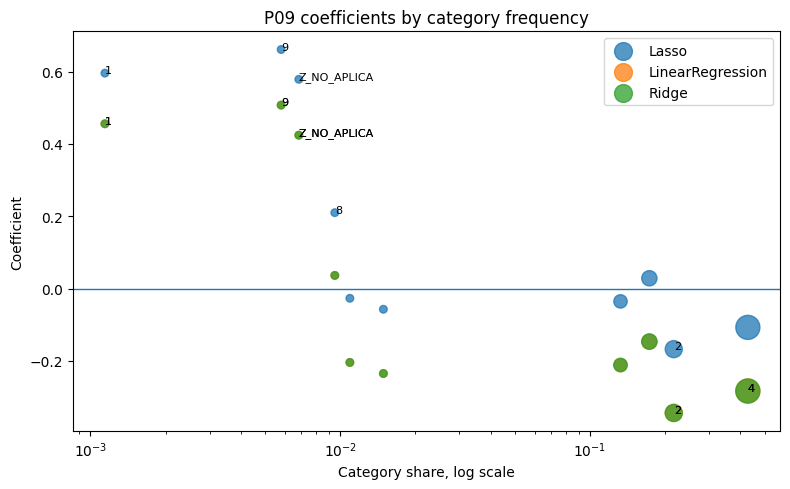

In [13]:
# P09 diagnostic figure: coefficient magnitude by category share.
if not T5_p09_category_audit.empty:
    plot_df = T5_p09_category_audit.dropna(subset=["model", "coefficient"]).copy()

    fig, ax = plt.subplots(figsize=(8, 5))

    for model_name, g in plot_df.groupby("model"):
        ax.scatter(
            g["share"],
            g["coefficient"],
            s=np.clip(g["n"] / g["n"].max() * 300, 30, 300),
            alpha=0.75,
            label=model_name,
        )

        # Label the most influential P09 categories.
        label_g = g.sort_values("abs_coefficient", ascending=False).head(5)
        for _, row in label_g.iterrows():
            ax.annotate(str(row["P09"]), (row["share"], row["coefficient"]), fontsize=8)

    ax.axhline(0, linewidth=1)
    ax.set_xscale("log")
    ax.set_xlabel("Category share, log scale")
    ax.set_ylabel("Coefficient")
    ax.set_title("P09 coefficients by category frequency")
    ax.legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR / "F5_p09_coefficients_by_category_share.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("No P09 audit table available.")

## 08. Low-frequency categorical levels diagnostic

In [14]:
T7_low_frequency_categories = pd.DataFrame()

if DATASET_PATH.exists() and dataset_card is not None:
    categorical_cols = dataset_card["metadata"].get("categorical_columns", [])
    categorical_cols = [c for c in categorical_cols if c in feature_columns]

    if categorical_cols:
        cat_df = pd.read_parquet(DATASET_PATH, columns=categorical_cols)

        low_pop_rows = []
        for col in categorical_cols:
            vc = cat_df[col].astype(str).value_counts(dropna=False)
            total = vc.sum()

            for level, n in vc.items():
                low_pop_rows.append({
                    "feature": col,
                    "level": level,
                    "n": int(n),
                    "share": float(n / total),
                    "is_low_count_lt_100": bool(n < 100),
                    "is_low_share_lt_0p005": bool((n / total) < 0.005),
                })

        T7_low_frequency_categories = pd.DataFrame(low_pop_rows)
        T7_low_frequency_categories["flag_low_pop"] = (
            T7_low_frequency_categories["is_low_count_lt_100"]
            | T7_low_frequency_categories["is_low_share_lt_0p005"]
        )

        T7_low_frequency_categories.to_csv(TABLE_DIR / "T7_low_frequency_categories.csv", index=False)

        display(
            T7_low_frequency_categories
            .query("flag_low_pop")
            .sort_values(["feature", "n"])
            .head(100)
        )
    else:
        print("No categorical columns found for low-frequency audit.")
else:
    print("Could not build low-frequency category diagnostic.")

,feature,level,n,share,is_low_count_lt_100,is_low_share_lt_0p005,flag_low_pop
93,CAT_INAC,5,150,0.000420,False,True,True
92,CAT_INAC,2,933,0.002615,False,True,True
98,CAT_OCUP,4,446,0.001250,False,True,True
124,CONDACT,9,1020,0.002859,False,True,True
52,H05,9.0,6,0.000017,True,True,True
51,H05,4.0,557,0.001561,False,True,True
50,H05,3.0,1246,0.003492,False,True,True
60,H06,6.0,175,0.000490,False,True,True
65,H08,3.0,481,0.001348,False,True,True
69,H09,3.0,218,0.000611,False,True,True


## 09. Bias-variance proxy figures

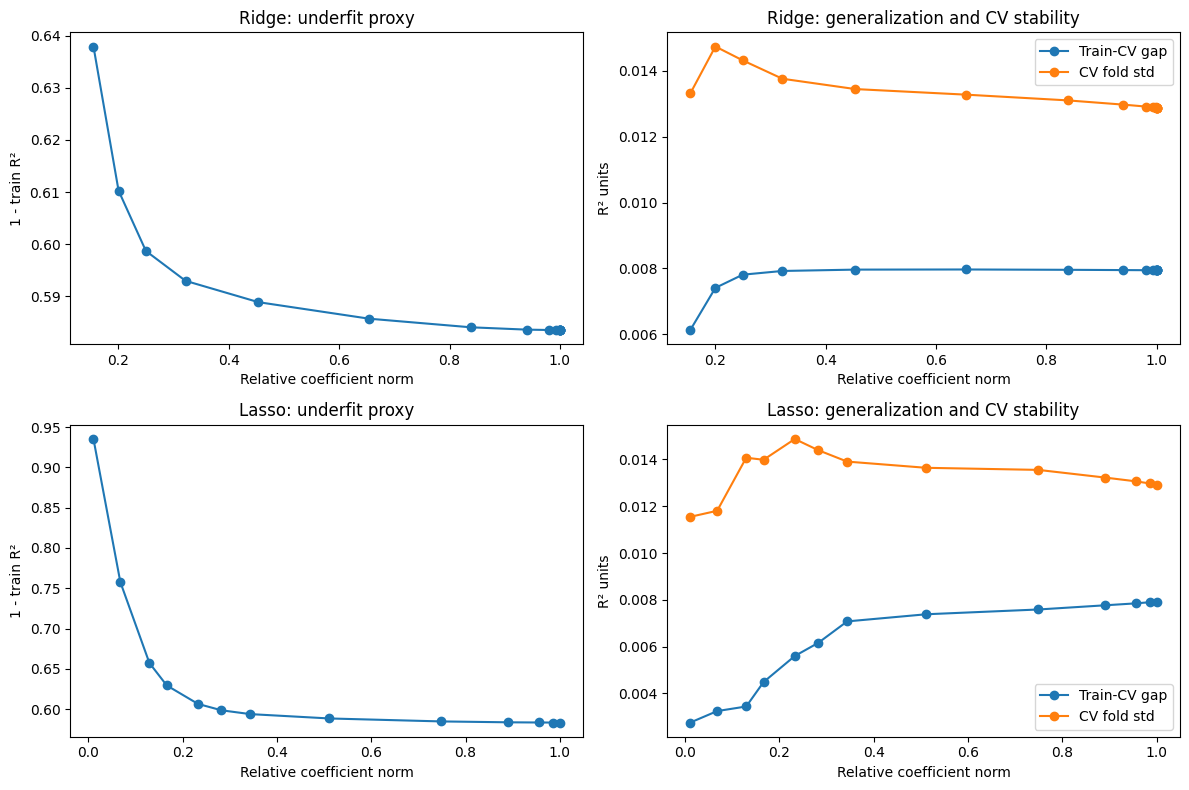

In [15]:
# Split-scale proxy figure: underfit on one panel, gap and CV instability on another.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, (model_name, norm_col) in enumerate([("Ridge", "relative_l2_norm"), ("Lasso", "relative_l1_norm")]):
    df = bias_variance_proxy.query("model == @model_name").dropna(subset=[norm_col]).sort_values(norm_col)

    axes[row, 0].plot(df[norm_col], df["underfit_proxy"], marker="o")
    axes[row, 0].set_xlabel("Relative coefficient norm")
    axes[row, 0].set_ylabel("1 - train R²")
    axes[row, 0].set_title(f"{model_name}: underfit proxy")

    axes[row, 1].plot(df[norm_col], df["generalization_gap"], marker="o", label="Train-CV gap")
    axes[row, 1].plot(df[norm_col], df["cv_instability"], marker="o", label="CV fold std")
    axes[row, 1].set_xlabel("Relative coefficient norm")
    axes[row, 1].set_ylabel("R² units")
    axes[row, 1].set_title(f"{model_name}: generalization and CV stability")
    axes[row, 1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "F6_bias_variance_proxies_split_scale.png", dpi=180, bbox_inches="tight")
plt.show()

## 10. Book-style error proxy plots

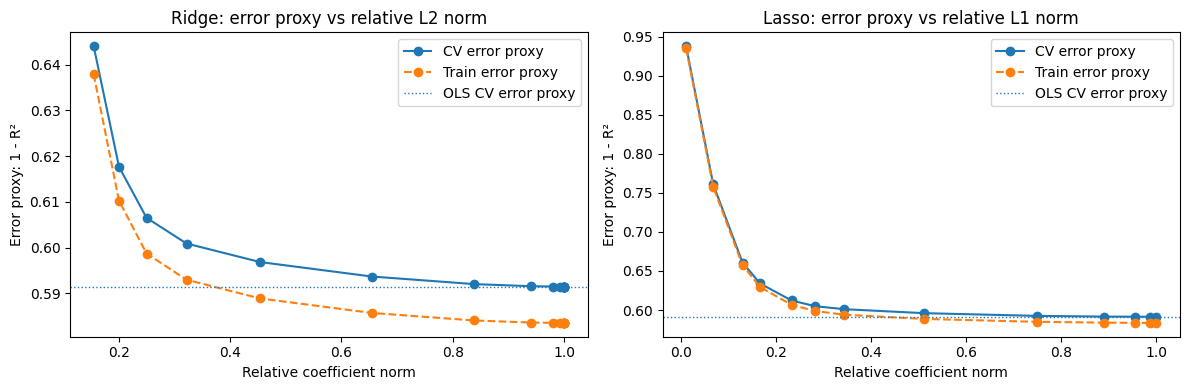

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ridge_book = regularization_path.query("model == 'Ridge'").dropna(subset=["relative_l2_norm"]).sort_values("relative_l2_norm")
lasso_book = regularization_path.query("model == 'Lasso'").dropna(subset=["relative_l1_norm"]).sort_values("relative_l1_norm")

if not ridge_book.empty:
    axes[0].plot(ridge_book["relative_l2_norm"], ridge_book["cv_error_proxy"], marker="o", label="CV error proxy")
    axes[0].plot(ridge_book["relative_l2_norm"], ridge_book["train_error_proxy"], marker="o", linestyle="--", label="Train error proxy")
    axes[0].axhline(1 - ols_cv_r2, linewidth=1, linestyle=":", label="OLS CV error proxy")
    axes[0].set_xlabel("Relative coefficient norm")
    axes[0].set_ylabel("Error proxy: 1 - R²")
    axes[0].set_title("Ridge: error proxy vs relative L2 norm")
    axes[0].legend()

if not lasso_book.empty:
    axes[1].plot(lasso_book["relative_l1_norm"], lasso_book["cv_error_proxy"], marker="o", label="CV error proxy")
    axes[1].plot(lasso_book["relative_l1_norm"], lasso_book["train_error_proxy"], marker="o", linestyle="--", label="Train error proxy")
    axes[1].axhline(1 - ols_cv_r2, linewidth=1, linestyle=":", label="OLS CV error proxy")
    axes[1].set_xlabel("Relative coefficient norm")
    axes[1].set_ylabel("Error proxy: 1 - R²")
    axes[1].set_title("Lasso: error proxy vs relative L1 norm")
    axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "diagnostic_book_style_error_proxy_vs_relative_norm.png", dpi=180, bbox_inches="tight")
plt.show()

## 11. Save full intermediate tables

In [17]:
# Save intermediate tables too. These are useful for debugging and later thesis writing.
regularization_path.to_csv(TABLE_DIR / "intermediate_regularization_path.csv", index=False)
coef_table.to_csv(TABLE_DIR / "intermediate_coef_table.csv", index=False)
bias_variance_proxy.to_csv(TABLE_DIR / "intermediate_bias_variance_proxy.csv", index=False)
error_by_decile.to_csv(TABLE_DIR / "intermediate_error_by_decile.csv", index=False)
prediction_distribution_summary.to_csv(TABLE_DIR / "intermediate_prediction_distribution_summary.csv", index=False)

findings = {
    "regularization_run": str(RUN_REG),
    "hgb_reference_run": str(RUN_HGB) if RUN_HGB is not None else None,
    "final_tables": sorted(p.name for p in TABLE_DIR.glob("T*.csv")),
    "final_figures": sorted(p.name for p in FIG_DIR.glob("F*.png")),
    "core_interpretation": [
        "Best Ridge and best Lasso are very close to OLS.",
        "Ridge shrinkage reduces coefficient norm but does not improve CV R2.",
        "Lasso shows limited redundancy but no highly sparse solution with comparable performance.",
        "Linear models show similar prediction compression and decile residual patterns.",
        "P09 categories dominate top coefficients and should be audited before final interpretation.",
    ],
    "future_backend_gaps": [
        "Add coefficient_path_long.csv by alpha and transformed feature.",
        "Add low-frequency category guard/collapser.",
        "Consider standardized transformed design for final coefficient-path figures.",
        "Run a stronger CV design for final regularization estimates if time allows.",
    ],
}

with open(OUTPUT_DIR / "findings.json", "w") as f:
    json.dump(findings, f, indent=2)

print("Saved final tables to:", TABLE_DIR)
print("Saved final figures to:", FIG_DIR)
print(json.dumps(findings, indent=2))

Saved final tables to: /home/matias/repos/income-modeling-eph/reports/notebook_outputs/regularization_ridge_lasso_final/tables
Saved final figures to: /home/matias/repos/income-modeling-eph/reports/notebook_outputs/regularization_ridge_lasso_final/figures
{
  "regularization_run": "/home/matias/repos/income-modeling-eph/reports/runs/regularization_sweep_v1_20260609T062726Z",
  "hgb_reference_run": "/home/matias/repos/income-modeling-eph/reports/runs/hgb_quick_benchmark_v1_20260609T061007Z",
  "final_tables": [
    "T1_model_regularization_summary.csv",
    "T2_regularization_path_representative_points.csv",
    "T3_selection_rules_best_vs_parsimonious.csv",
    "T4_top_feature_families.csv",
    "T5_p09_category_audit.csv",
    "T6_distribution_error_summary.csv",
    "T7_low_frequency_categories.csv",
    "T8_top_feature_overlap.csv"
  ],
  "final_figures": [
    "F1_ridge_shrinkage_cv_vs_l2_ratio.png",
    "F2_lasso_sparsity_cv_vs_active_ratio.png",
    "F3_regularization_decile_erro